# Phase 2 — Version A: the full Turkish saver's menu

**Study:** dual_momentum_turkish_investor · SPEC §2/§3/§3a/§4/§6a

Universe: 10 USD ETF sleeves + rolled TL deposits (`TP.TRY.MT02` flow, weekly compounding) +
BIST-100 total return (`TP.MK.G.BILESIK`). **All signals in nominal TL** (USD sleeves × same-date
Wednesday USDTRY mid, TCMB); signal series = accounting series. Two-way escape hatch: failed
absolute-filter slots go to the higher 10w-RoC of {TL deposits, SHY-in-TL}. L ∈ {10,25}, N=3,
50/50 blend, EM gate, costs 10 bps one-way (deposits 0), 25 bps sensitivity.
Benchmarks B1–B6 per SPEC §4. CPI = TÜİK 2025=100 via EVDS (current through 2026-07).
Window 2013-01-01 → latest; TL-real truncates at CPI's last month.

**Required output: the A−B gap** — VA_net10 minus VB_net10 in real TL, full period + regimes
(VB translated with the same TCMB fx + EVDS CPI for a clean comparison).

**Terminology (defined in [SPEC.md](SPEC.md) §3a/§4, restated here for readers landing on this notebook first):**
**Version A** = the full Turkish saver's universe — the ten USD ETF sleeves *plus* rolled TL time deposits and BIST-100 total return, with all momentum signals computed in nominal TL (Phase 2).
**Version B** = the implementable subset — the ten USD ETF sleeves only, signals in USD, escape hatch = SHY; everything executable at a single broker today (this notebook).
**A−B gap** = the real-TL performance difference between them: what access to the TL deposit layer is worth to a Turkish investor — the study's key product-relevant output, computed in Phase 2.
**B1–B6** = the fixed benchmark set: B1 rolled TL deposits, B2 100% SHY ("hold dollars"), B3 100% gold, B4 BIST-100 total return, B5 equal-weight of the universe, B6 50/50 deposits/BIST (stylized retail portfolio).


In [1]:
import numpy as np
import pandas as pd
from phase2_version_a import run_phase2, UNIVERSE_A

res = run_phase2()
pd.set_option("display.float_format", lambda x: "%0.4f" % x)
print("=== TL real (headline; to CPI %s) ===" % res["cpi_last"])
print(res["tables"]["TL_real"].to_string())
print()
print("=== USD ===")
print(res["tables"]["USD"].to_string())

=== TL real (headline; to CPI 2026-07-01) ===
              perf  st_dev  max_dd  sharpe  calmar    weeks
VA_gross    0.1364  0.1913 -0.2542  0.7130  0.5366 708.0000
VA_net10    0.1174  0.1915 -0.2705  0.6130  0.4341 708.0000
VA_net25    0.0896  0.1920 -0.2944  0.4666  0.3042 708.0000
B1_deposits 0.0096  0.0862 -0.4925  0.1118  0.0196 708.0000
B2_SHY_TL   0.0374  0.1664 -0.4154  0.2249  0.0901 708.0000
B3_GLD_TL   0.0869  0.2125 -0.2952  0.4087  0.2942 708.0000
B4_BIST     0.0162  0.2600 -0.4600  0.0624  0.0353 708.0000
B5_EW       0.0926  0.1667 -0.2813  0.5555  0.3293 708.0000
B6_50_50    0.0213  0.1457 -0.2466  0.1465  0.0866 708.0000
VB_net10    0.1126  0.1971 -0.3382  0.5714  0.3329 706.0000

=== USD ===
               perf  st_dev  max_dd  sharpe  calmar    weeks
VA_gross     0.1123  0.1295 -0.1694  0.8669  0.6626 712.0000
VA_net10     0.0937  0.1299 -0.1805  0.7216  0.5192 712.0000
VA_net25     0.0665  0.1305 -0.2070  0.5094  0.3210 712.0000
B1_deposits -0.0115  0.1464 -0.7022 -

C:\Users\mtulum\Dropbox\obsidianVault\raw\studies\dual_momentum_turkish_investor\engine.py:179: RuntimeWarning: divide by zero encountered in scalar divide
  "sharpe": perf / stdev, "calmar": perf / abs(dd),


In [2]:
print("=== TL nominal ===")
print(res["tables"]["TL_nominal"].to_string())
print()
for k, v in res["holdings"].items():
    print("%s: %0.3f" % (k, v))
w = res["weights"]
print()
print("avg blend weight by year (%):")
print((w.groupby(w.index.year)[["DEPOSIT_TL", "BIST_TL"]].mean() * 100).round(1).to_string())

=== TL nominal ===
              perf  st_dev  max_dd  sharpe  calmar    weeks
VA_gross    0.4146  0.1801 -0.2045  2.3015  2.0274 712.0000
VA_net10    0.3910  0.1804 -0.2072  2.1667  1.8868 712.0000
VA_net25    0.3563  0.1810 -0.2113  1.9690  1.6863 712.0000
B1_deposits 0.2572  0.0236  0.0000 10.9124     inf 712.0000
B2_SHY_TL   0.2896  0.1529 -0.2133  1.8946  1.3581 712.0000
B3_GLD_TL   0.3635  0.2045 -0.2392  1.7776  1.5195 712.0000
B4_BIST     0.2679  0.2558 -0.3176  1.0475  0.8438 712.0000
B5_EW       0.3624  0.1531 -0.2212  2.3674  1.6382 712.0000
B6_50_50    0.2730  0.1288 -0.1544  2.1192  1.7685 712.0000
VB_net10    0.3876  0.1857 -0.2519  2.0876  1.5389 710.0000

mean_weekly_oneway_turnover: 0.353
avg_sleeves_held: 4.356
pct_weeks_in_deposit_sleeve: 0.296
avg_deposit_weight_when_held: 0.248
pct_weeks_hatch_triggered: 0.028

avg blend weight by year (%):
      DEPOSIT_TL  BIST_TL
Date                     
2013      0.0000  11.9000
2014      0.3000  11.3000
2015      4.2000   3.5

In [3]:
print("=== A-B gap table — real-TL annualized returns (%), SPEC section 7 ===")
print((res["gap"] * 100).round(1).to_string())

=== A-B gap table — real-TL annualized returns (%), SPEC section 7 ===
                         VA_net10  VB_net10  B1_deposits  B2_SHY_TL  B4_BIST  B6_50_50   B5_EW  A_minus_B_gap
window                                                                                                       
full period               11.7000   11.2000       1.0000     3.7000   1.6000    2.1000  9.2000         0.5000
2013-2017 pre-crisis      14.8000   14.7000       2.0000     7.6000   1.0000    2.1000 12.1000         0.1000
2018 crisis               16.2000   11.1000      -0.1000    19.7000 -31.8000  -16.9000  3.1000         5.0000
2019-2020 COVID           13.4000   14.0000       2.9000     8.5000  17.2000   10.7000 20.5000        -0.5000
2021-2023H1 infl. surge   23.5000   17.6000     -16.8000    10.5000  20.2000    1.5000 12.8000         6.0000
2023H2-present orthodox   -1.5000    1.9000      19.1000    -9.9000  -5.9000    6.7000  0.5000        -3.3000


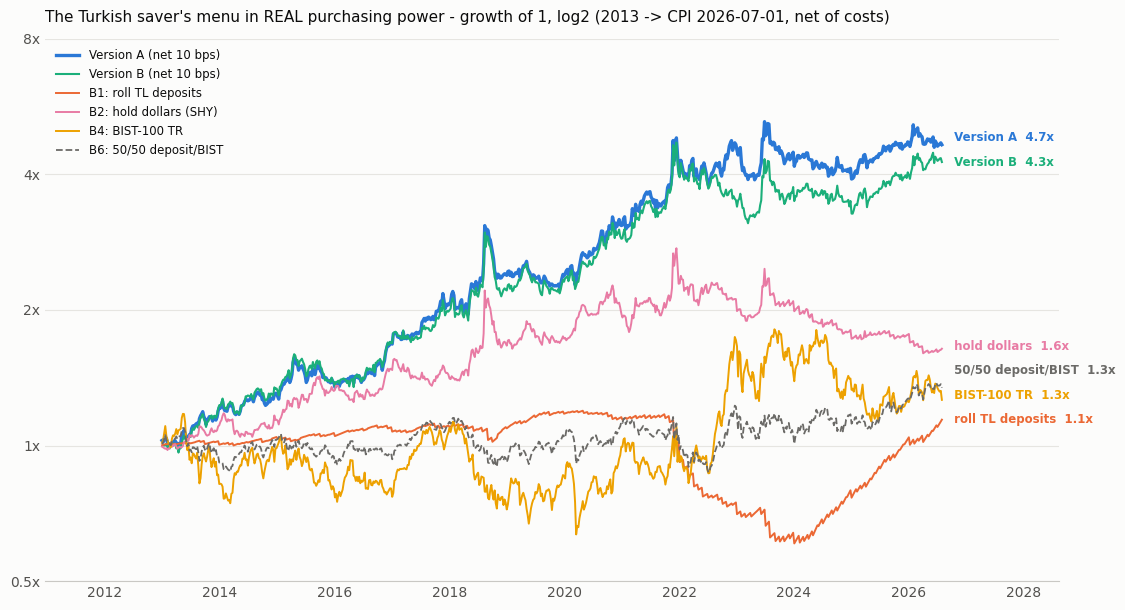

In [4]:
import matplotlib.pyplot as plt

SURFACE = "#fcfcfb"
STYLE = {
    "VA_net10":    dict(color="#2a78d6", lw=2.4, ls="-",  label="Version A (net 10 bps)"),
    "VB_net10":    dict(color="#1baf7a", lw=1.5, ls="-",  label="Version B (net 10 bps)"),
    "B1_deposits": dict(color="#eb6834", lw=1.4, ls="-",  label="B1: roll TL deposits"),
    "B2_SHY_TL":   dict(color="#e87ba4", lw=1.4, ls="-",  label="B2: hold dollars (SHY)"),
    "B4_BIST":     dict(color="#eda100", lw=1.4, ls="-",  label="B4: BIST-100 TR"),
    "B6_50_50":    dict(color="#6b6a67", lw=1.3, ls="--", label="B6: 50/50 deposit/BIST"),
}
fig, ax = plt.subplots(figsize=(11.5, 6.2), facecolor=SURFACE)
ax.set_facecolor(SURFACE)
for name, st in STYLE.items():
    c = res["curves"][name]["TL_real"]
    ax.plot(c.index, np.log2(c.values), **st)
last = sorted((np.log2(res["curves"][n]["TL_real"].iloc[-1]), n) for n in STYLE)
prev = None
for y, n in last:
    if prev is not None and y - prev < 0.18:
        y = prev + 0.18
    prev = y
    c = res["curves"][n]["TL_real"]
    ax.annotate(" %s  %.1fx" % (STYLE[n]["label"].split(":")[-1].strip().split(" (")[0], c.iloc[-1]),
                xy=(c.index[-1], y), xytext=(6, 0), textcoords="offset points",
                va="center", color=STYLE[n]["color"], fontsize=8.5, fontweight="bold")
vals = [np.log2(res["curves"][n]["TL_real"].values) for n in STYLE]
lo, hi = min(v.min() for v in vals), max(v.max() for v in vals)
ticks = range(int(np.floor(lo)), int(np.ceil(hi)) + 1)
ax.set_yticks(list(ticks)); ax.set_yticklabels(["%gx" % (2.0 ** k) for k in ticks])
ax.grid(axis="y", color="#e6e5e1", lw=0.8)
for s in ["top", "right", "left"]:
    ax.spines[s].set_visible(False)
ax.spines["bottom"].set_color("#c9c8c4")
ax.tick_params(colors="#52514e", length=0)
ax.set_title("The Turkish saver's menu in REAL purchasing power - growth of 1, log2 (2013 -> CPI %s, net of costs)" % res["cpi_last"],
             color="#0b0b0b", fontsize=11, loc="left", pad=12)
ax.legend(loc="upper left", frameon=False, fontsize=8.5, labelcolor="#0b0b0b")
ax.margins(x=0.15)
plt.tight_layout()
plt.savefig("results/version_a_real_tl_curves.png", dpi=150, bbox_inches="tight", facecolor=SURFACE)
plt.show()

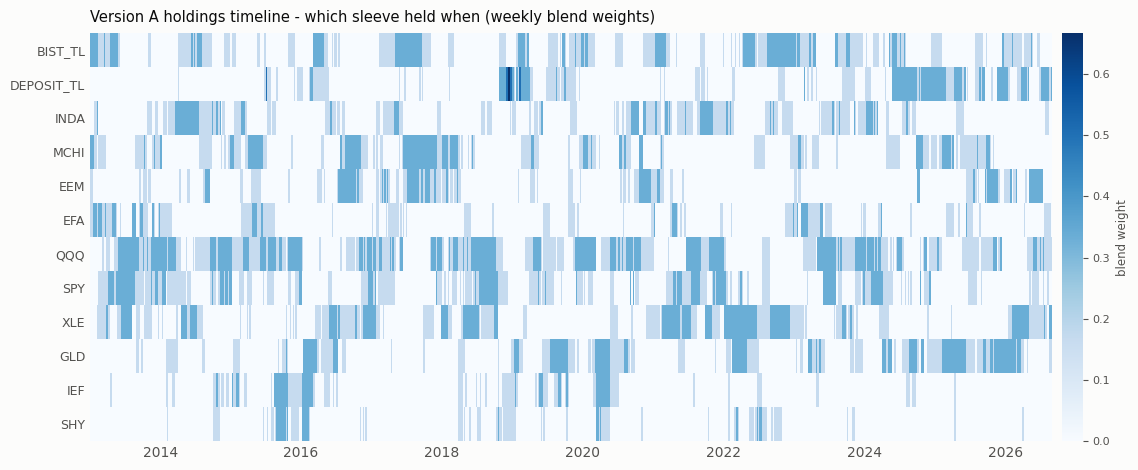

In [5]:
w = res["weights"][UNIVERSE_A]
fig, ax = plt.subplots(figsize=(11.5, 4.8), facecolor=SURFACE)
ax.set_facecolor(SURFACE)
mesh = ax.pcolormesh(w.index.append(w.index[-1:] + pd.Timedelta(weeks=1)),
                     np.arange(len(UNIVERSE_A) + 1), w.T.values,
                     cmap="Blues", vmin=0, vmax=2.0 / 3, shading="flat")
ax.set_yticks(np.arange(len(UNIVERSE_A)) + 0.5)
ax.set_yticklabels(UNIVERSE_A, fontsize=9, color="#0b0b0b")
ax.tick_params(colors="#52514e", length=0)
for s in ax.spines.values():
    s.set_visible(False)
cb = fig.colorbar(mesh, ax=ax, fraction=0.03, pad=0.01)
cb.set_label("blend weight", color="#52514e", fontsize=8.5)
cb.ax.tick_params(colors="#52514e", labelsize=8)
cb.outline.set_visible(False)
ax.set_title("Version A holdings timeline - which sleeve held when (weekly blend weights)",
             color="#0b0b0b", fontsize=10.5, loc="left", pad=8)
plt.tight_layout()
plt.savefig("results/version_a_holdings_timeline.png", dpi=150, bbox_inches="tight", facecolor=SURFACE)
plt.show()

## Results & Interpretation
*(revised 2026-08-29, incorporating the 2026-08-24 significance audit — see STUDY_LOG)*

**Headline (real TL, 2013 → last CPI month, net 10 bps):** Version A **4.7× (11.7%/yr, Sharpe 0.61)**.
The naive options cluster at 1.1–1.6× over the same 13½ years — deposits 1.1× (real DD −49%),
dollars 1.6×, BIST 1.3×, 50/50 1.3× — with gold the exception at 3.1×. The margins that clear
statistical significance: **vs deposits +11.6%/yr (t≈2.4), vs dollars +7.9 (t≈2.2)**. Not
significant: vs equal-weight (+2.7, t≈1.1) and vs gold alone (+2.3, t≈0.5) — momentum *selection*
is not demonstrably worth anything over holding the same 12 assets equally weighted.

**A−B gap:** +0.5%/yr full period, but VA and VB weekly real returns correlate **0.962**, and no
gap figure — full-period or regime-level — is distinguishable from zero. One country's 13 years
cannot answer what deposit integration is worth; cross-country pooling could.

**Mechanics:** deposits enter via *ranking* (29.6% of weeks, ~20% weight 2024–26), not the two-way
hatch, which fires only 2.8% of weeks — chronic depreciation keeps nominal-TL RoC positive. In the
2023H2→ window VA earned ≈0 real while deposits alone earned +18%/yr: the zero hurdle is
inflation-blind, and N=3 caps any sleeve at 1/3 (deposit weight sat at exactly 33% in all 161
weeks). Both diagnosed in the risk-free-hurdle robustness run (`phase3_robustness_deposit_hurdle.py`).

**Costs:** at 25 bps VA still earns 9.0%/yr real, above every naive option. Turnover 0.35/wk one-way.

**Caveats:** CPI = TÜİK 2025=100 via EVDS, publication lag ignored (reporting only); B5 EW is
costless; deposit roll frictionless at the flow rate. Outputs in `results/`.